In [349]:
import numpy as np

from TimeSeriesGenerator import EventFrequency, EventSampleSpace, TimeSeriesGenerator
from TreeBasedGenerator import Distribution

In [350]:
N = 8
time_intervals = [(i, i+1) for i in range(N)]
occurrences = [i+1 for i in range(N)]
periods_sds = [0.1]*N
no_occurrences_sds = [0]*N

print("Time intervals:", time_intervals)
print("Occurrences:", occurrences)
print("Period standard deviations:", periods_sds)
print("Number of occurrences standard deviations:", no_occurrences_sds)

Time intervals: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]
Occurrences: [1, 2, 3, 4, 5, 6, 7, 8]
Period standard deviations: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
Number of occurrences standard deviations: [0, 0, 0, 0, 0, 0, 0, 0]


In [351]:
class ExampleSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
    
    def sample(self, t):
        return np.random.normal(loc=1, scale=0)

In [352]:
EF = EventFrequency(occurrences, time_intervals, periods_sds, no_occurrences_sds)
ESS = ExampleSampleSpace()

In [353]:
def on_event(event):
    print(event)

time_series_generator = TimeSeriesGenerator([(EF, ESS)], on_event)
data = time_series_generator.run(N)

(1.0533335152643737, 1.0)
(1.475327402298905, 1.0)
(2.104650946555941, 1.0)
(2.455467492706293, 1.0)
(2.831234187986967, 1.0)
(3.2607760695026147, 1.0)
(3.5547418812651994, 1.0)
(3.8708470644021253, 1.0)
(4.182466466317403, 1.0)
(4.422462821302597, 1.0)
(4.761306318345684, 1.0)
(5.056896481279425, 1.0)
(5.247473296045457, 1.0)
(5.464840687235994, 1.0)
(5.626406861943275, 1.0)
(5.867765248531513, 1.0)
(6.10595613345923, 1.0)
(6.408423128618485, 1.0)
(6.480677453696442, 1.0)
(6.5840811297079345, 1.0)
(6.700330771314183, 1.0)
(6.701923028185374, 1.0)
(7.109516893805451, 1.0)
(7.111029748851591, 1.0)
(7.317295423263728, 1.0)
(7.367464279171753, 1.0)
(7.415807338905252, 1.0)
(7.458243014110381, 1.0)
(7.576231410091274, 1.0)
(7.6023397341795045, 1.0)
(7.791195728817555, 1.0)
(7.946237036800835, 1.0)


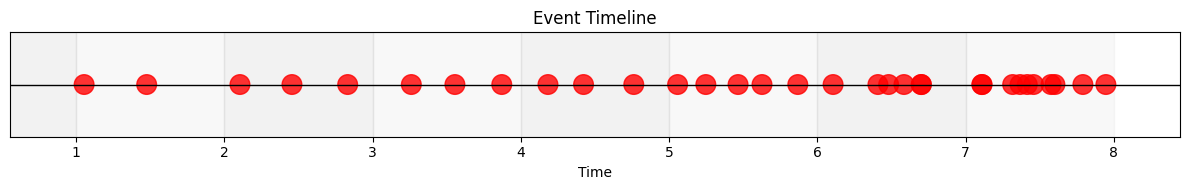

In [354]:
import matplotlib.pyplot as plt

# Assume `data` is a list of (time, scale) tuples,
# and `time_intervals` is a list of (start, end) tuples, already defined.

# Unpack times and scales
times, scales = zip(*data)

# All events sit on the same horizontal line
ys = [0] * len(times)

# Map scales to marker sizes (adjust the multiplier as needed)
marker_sizes = [s * 200 for s in scales]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Draw baseline timeline
ax.hlines(0, min(times) - 0.5, max(times) + 0.5, color='black', linewidth=1)

# Shade each period for context
for idx, (start, end) in enumerate(time_intervals):
    alpha = 0.1 if idx % 2 == 0 else 0.05
    ax.axvspan(start, end, color='gray', alpha=alpha)

# Plot events as red circles
ax.scatter(times, ys, s=marker_sizes, color='red', alpha=0.8)

# Hide y-axis ticks and labels
ax.set_yticks([])

# Labels and title
ax.set_xlabel('Time')
ax.set_title('Event Timeline')

# Set plot limits
ax.set_xlim(min(times) - 0.5, max(times) + 0.5)
ax.set_ylim(-0.5, 0.5)

plt.tight_layout()
plt.show()
